<div style='text-align: center; padding: 30px'>
  <h1><strong>Time Series</strong></h1>
  <h3><strong>Heriberto Espino Montelongo</strong></h1>
</div>

Son muchas, solo vamos a plottear las que vamos a usar en nuestros portafolios.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
file = r'cryptos-index.csv'
data = pd.read_csv(file, index_col="Date", parse_dates=True)

In [4]:
# min max to 0-1
minmax = (data - data.min()) / (data.max() - data.min())

In [5]:
portfoliobuy = ['XRP', 'TRX', 'LEO', 'PP']
portfoliobuy = minmax[portfoliobuy]

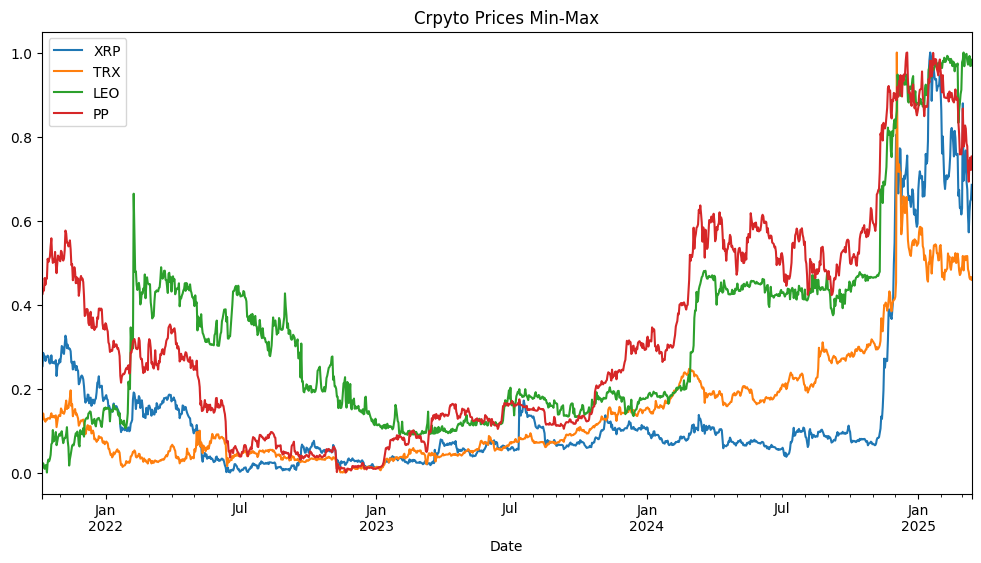

In [6]:
# plot the price of the portfolio
portfoliobuy.plot(figsize=(12, 6))
plt.title('Crpyto Prices Min-Max')
plt.show()

**NOOOOOO!** Tuvieron unas subidotas, no sé si vaya a salir bien...

In [7]:
pbuy = ['XRP', 'TRX', 'LEO', 'PP']
pbuy = data[pbuy]

In [8]:
# create an 'index' column in the portfolio with this weight
# XRP 0.06577
# TRX 0.22764
# LEO 0.70659

pbuy.loc[:, 'Portfolio'] = pbuy['XRP'] * 0.06577 + pbuy['TRX'] * 0.22764 + pbuy['LEO'] * 0.70659

/tmp/ipykernel_35968/2222406515.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pbuy.loc[:, 'Portfolio'] = pbuy['XRP'] * 0.06577 + pbuy['TRX'] * 0.22764 + pbuy['LEO'] * 0.70659


In [9]:
pbuy

,XRP,TRX,LEO,PP,Portfolio
Date,,,,,
2021-10-07 00:00:00+00:00,1.068026,0.095514,2.899025,46625.150251,2.140409
2021-10-08 00:00:00+00:00,1.062891,0.097670,2.780317,46759.770727,2.056684
2021-10-09 00:00:00+00:00,1.159926,0.102870,2.838253,47620.269502,2.105187
2021-10-10 00:00:00+00:00,1.138453,0.097748,2.769014,47435.634377,2.053685
2021-10-11 00:00:00+00:00,1.137888,0.097162,2.742823,49773.467955,2.035008
...,...,...,...,...,...
2025-03-10 00:00:00+00:00,2.018294,0.229486,9.747614,67655.560543,7.072550
2025-03-11 00:00:00+00:00,2.166916,0.224426,9.882753,71379.506151,7.176661
2025-03-12 00:00:00+00:00,2.240755,0.222995,9.709141,72115.729729,7.058519


Text(0.5, 1.0, 'Crpyto Prices Portfolio Raw')

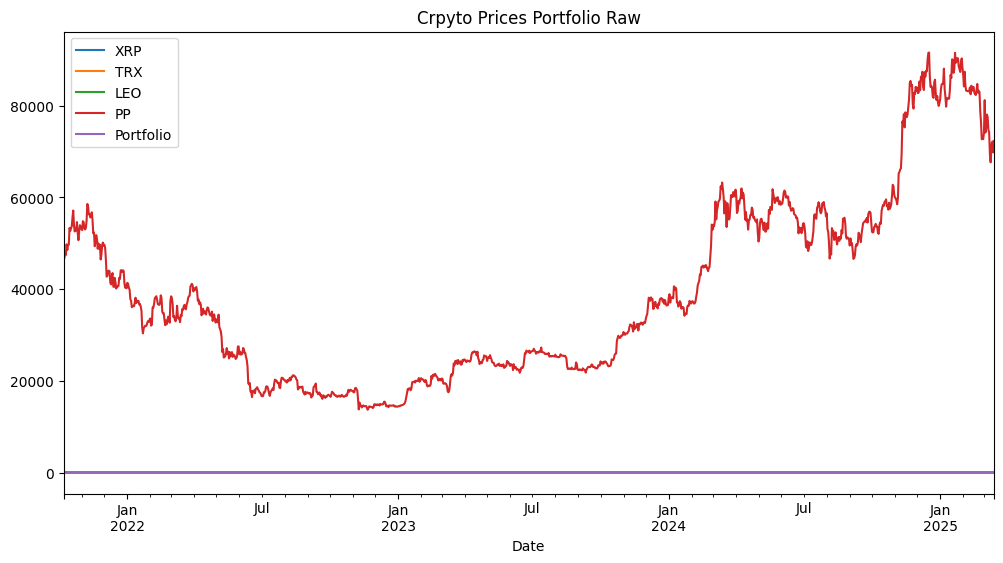

In [10]:
pbuy.plot(figsize=(12, 6))
plt.title('Crpyto Prices Portfolio Raw')

In [11]:
# create an 'index' column in the portfolio with this weight
# XRP 0.06577
# TRX 0.22764
# LEO 0.70659

portfoliobuy.loc[:, 'Portfolio'] = portfoliobuy['XRP'] * 0.06577 + portfoliobuy['TRX'] * 0.22764 + portfoliobuy['LEO'] * 0.70659

/tmp/ipykernel_35968/1786087127.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  portfoliobuy.loc[:, 'Portfolio'] = portfoliobuy['XRP'] * 0.06577 + portfoliobuy['TRX'] * 0.22764 + portfoliobuy['LEO'] * 0.70659


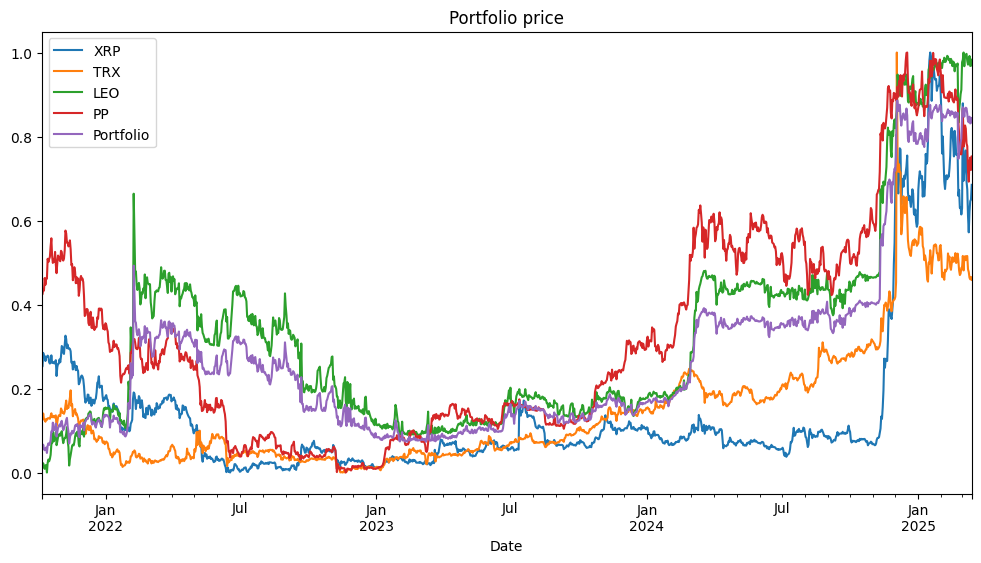

In [12]:
# plot the price of the portfolio
portfoliobuy.plot(figsize=(12, 6))
plt.title("Portfolio price")
plt.show()

In [13]:
returns = portfoliobuy.pct_change().dropna()

In [14]:
returns

,XRP,TRX,LEO,PP,Portfolio
Date,,,,,
2021-10-08 00:00:00+00:00,-0.006757,0.047407,-0.539209,0.004087,-0.157691
2021-10-09 00:00:00+00:00,0.128557,0.109166,0.571113,0.026020,0.197402
2021-10-10 00:00:00+00:00,-0.025208,-0.096945,-0.434428,-0.005441,-0.155656
2021-10-11 00:00:00+00:00,-0.000680,-0.012282,-0.290556,0.069276,-0.052128
2021-10-12 00:00:00+00:00,-0.043419,-0.035076,0.953703,-0.034475,0.078096
...,...,...,...,...,...
2025-03-10 00:00:00+00:00,-0.063664,-0.013317,0.001919,-0.032190,-0.003235
2025-03-11 00:00:00+00:00,0.086903,-0.028197,0.019118,0.069005,0.016010
2025-03-12 00:00:00+00:00,0.039724,-0.008206,-0.024100,0.012762,-0.019039


# **PORTFOLIO**

In [15]:
investment_list = []
investment = 1

for day in range(0, len(returns)):
    investment = (1 + returns['Portfolio'].iloc[day]) * investment
    investment_list.append(investment)

investment_mspob = pd.Series(investment_list, index=returns.index)  # Investment Max Sharpe Portfolio Only Buy

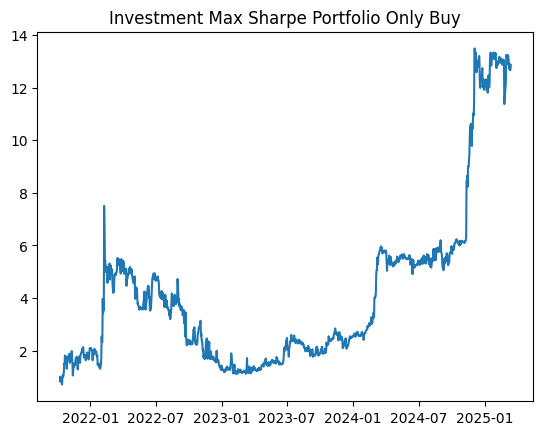

In [16]:
investment_list = []
investment = 1

for day in range(len(returns) - 720, len(returns)):
    investment = (1 + returns['Portfolio'].iloc[day]) * investment
    investment_list.append(investment)

# plot the investment
plt.plot(investment_mspob)
plt.title('Investment Max Sharpe Portfolio Only Buy')
plt.show()

<Axes: xlabel='Date'>

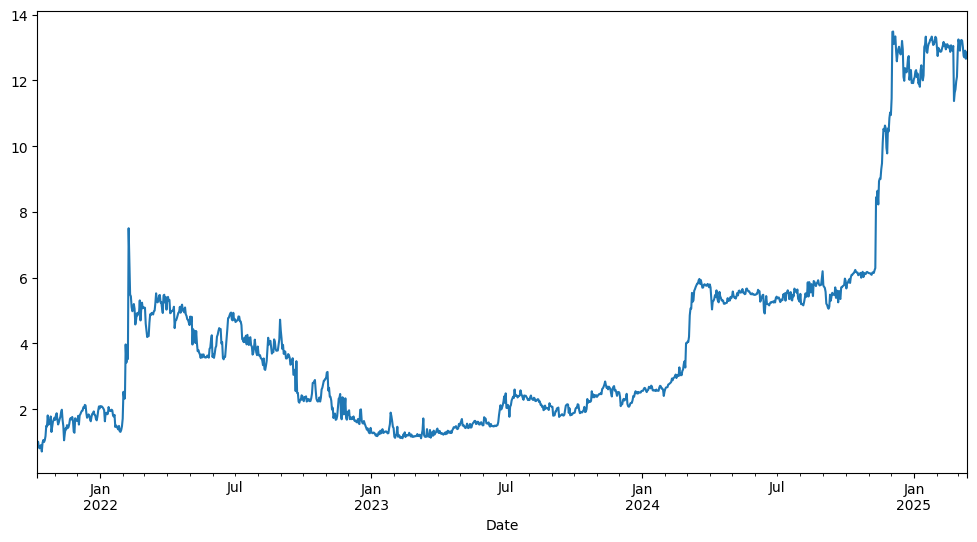

In [17]:
investment_mspob.plot(figsize=(12, 6))

# **PONDERED PORTFOLIO**

In [18]:
investment_list = []
investment = 1

for day in range(0, len(returns)):
    
    investment = (1 + returns['PP'].iloc[day]) * investment
    investment_list.append(investment)
    

investment_ppob = pd.Series(investment_list, index=returns.index)  # Investment Ponderated Portfolio Only Buy

/tmp/ipykernel_35968/2666205419.py:6: RuntimeWarning: invalid value encountered in scalar multiply
  investment = (1 + returns['PP'].iloc[day]) * investment


<Axes: xlabel='Date'>

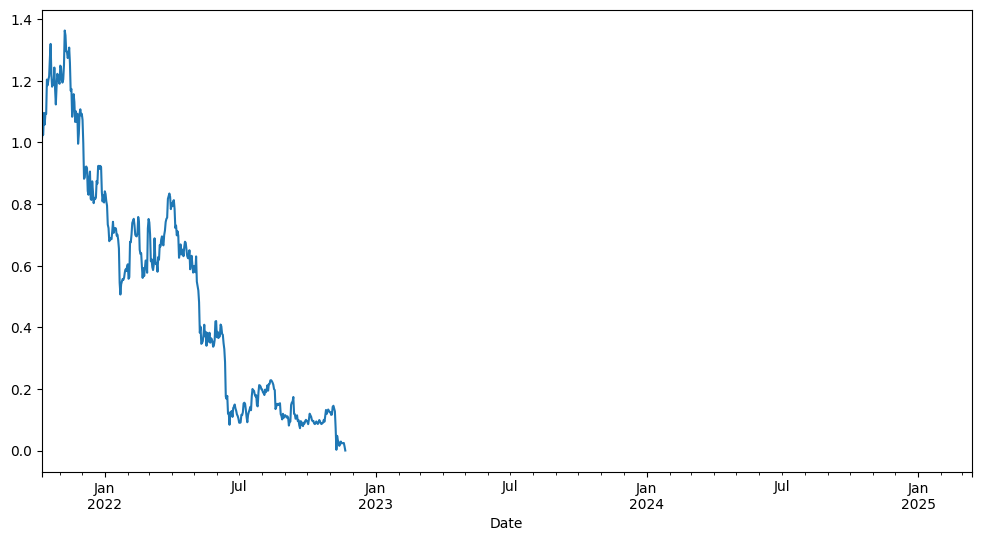

In [19]:
investment_ppob.plot(figsize=(12, 6))

# **COMPARE**

In [171]:
comparison = pd.DataFrame({'Investment Max Sharpe Portfolio Only Buy': investment_mspob,
                           'Investment Ponderated Portfolio Only Buy': investment_ppob})

<Axes: xlabel='Date'>

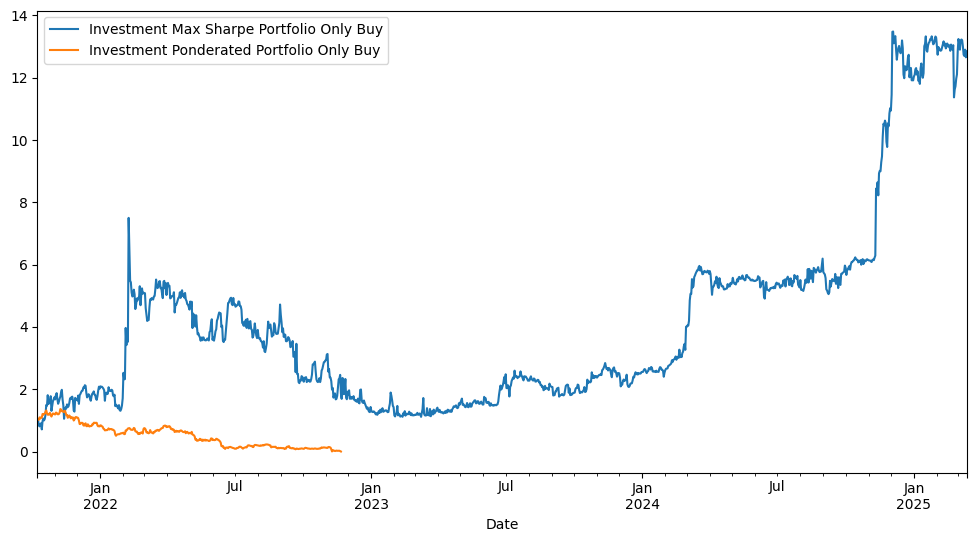

In [172]:
comparison.plot(figsize=(12, 6))

# **CFD PORTFOLIO**

Son muchas, solo vamos a plottear las que vamos a usar en nuestros portafolios.

In [ ]:
file = r'cryptos-index.csv'
data = pd.read_csv(file, index_col="Date", parse_dates=True)

In [ ]:
weights = pd.read_csv('portfolio-cfd.csv')

In [ ]:
pcfd = data  # portfolio cfd

In [ ]:
returns = pcfd.pct_change()
returns = returns.dropna()

In [ ]:
# get the weights 
for w in weights.columns:                       # for each crypto
    returns[w] = returns[w] * weights[w][0]     # multiply by the weight 

In [ ]:
returns['Portfolio'] = returns.sum(axis=1)    # sum the columns to get the portfolio return

Text(0.5, 1.0, 'Portfolio performance')

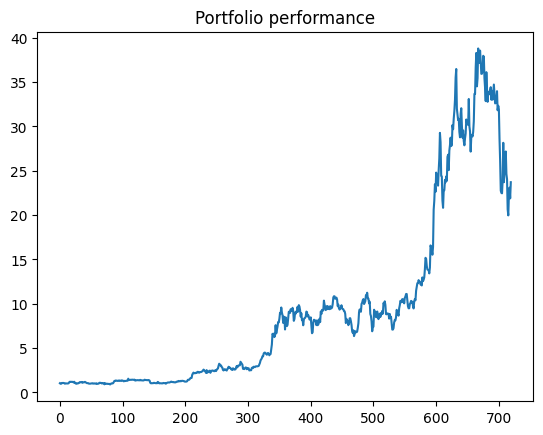

In [ ]:
investment_list = []
investment = 1

for day in range(len(returns) - 720, len(returns)):
    investment = (1 + returns['Portfolio'].iloc[day]) * investment
    investment_list.append(investment)

# Plot the cumulative returns
plt.plot(investment_list)
plt.title('Portfolio performance')